# KLTN — V2.2: Ensemble V1.4 (LSTM-CNN) + V2.0 (ST-GCN)

**Mục tiêu:** Vượt ngưỡng F1 ≥ 0,80 bằng weighted soft-voting giữa hai mô hình bổ trợ.

## Cơ sở

Bảng 3.3 ở báo cáo cho thấy V1.4 và V2.0 không cùng giỏi trên cùng seed:
- Seed 7: V1.4 thắng (0,8050 vs 0,7220)
- Seed 42: V2.0 đại thắng (0,8193 vs 0,7591)
- Các seed khác: V2.0 thắng nhẹ

→ Hai mô hình học pattern khác nhau, có thể bổ trợ qua ensemble.

## Phương pháp

Với mỗi seed (5 seeds):
1. Load V1.4 checkpoint (.keras) và V2.0 checkpoint (.pt)
2. Predict softmax probability trên TEST set cho từng model
3. Kết hợp: `p_final = α · p_V14 + β · p_V20`, với α + β = 1
4. Grid search α ∈ {0.0, 0.05, ..., 1.0} trên VAL set (tối ưu F1-macro)
5. Áp dụng α tối ưu lên TEST set → báo cáo F1

**KHÔNG cần train mới.** Chỉ predict + grid search → ~5 phút/seed.

## 1. Setup

In [ ]:
!rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
ROOT_DIR = "/content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco"
V14_DIR = f"{ROOT_DIR}/training_outputs/v1.4_stratified"
V20_DIR = f"{ROOT_DIR}/training_outputs/v2.0_stgcn"
OUT_DIR = f"{ROOT_DIR}/training_outputs/v2.2_ensemble"
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.exists(V14_DIR), f"Thiếu V1.4 checkpoints ở {V14_DIR}"
assert os.path.exists(V20_DIR), f"Thiếu V2.0 checkpoints ở {V20_DIR}"
print(f"V1.4: {V14_DIR}")
print(f"V2.0: {V20_DIR}")
print(f"OUT:  {OUT_DIR}")

V1.4: /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/v1.4_stratified
V2.0: /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/v2.0_stgcn
OUT:  /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/v2.2_ensemble


In [ ]:
import os, json, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
print("TF:", tf.__version__, "Torch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TF: 2.20.0 Torch: 2.10.0+cu128


## 2. Define lại V1.4 model + V2.0 model + Focal loss

(cần lại để load checkpoint)

In [ ]:
# V1.4 Focal Loss (Keras)
def focal_loss_keras(alpha=0.25, gamma=2.0):
    def f(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        oh = tf.cast(tf.one_hot(y_true, depth=tf.shape(y_pred)[-1]), y_pred.dtype)
        p = tf.clip_by_value(y_pred, 1e-8, 1 - 1e-8)
        ce = -oh * tf.math.log(p)
        return tf.reduce_mean(tf.reduce_sum(alpha * tf.math.pow(1 - p, gamma) * ce, axis=-1))
    return f

In [ ]:
# V2.0 ST-GCN (cần re-define để load weights)
COCO_17_EDGES = [(0,1),(0,2),(1,3),(2,4),(5,0),(6,0),(5,6),(5,7),(7,9),(6,8),(8,10),
                 (5,11),(6,12),(11,12),(11,13),(13,15),(12,14),(14,16)]
V_JOINTS = 17
CENTER_JOINT = 0

def bfs_dist(adj, root):
    V = adj.shape[0]; dist = -np.ones(V, dtype=np.int32); dist[root] = 0
    fr = [root]
    while fr:
        nf = []
        for u in fr:
            for v in range(V):
                if adj[u,v] > 0 and dist[v] == -1:
                    dist[v] = dist[u] + 1; nf.append(v)
        fr = nf
    if (dist == -1).any(): dist[dist == -1] = dist.max() + 1
    return dist

def _norm(A):
    D = A.sum(0); Di = np.zeros_like(D, dtype=np.float32); Di[D > 0] = D[D > 0] ** -0.5
    return np.diag(Di) @ A @ np.diag(Di)

def build_adjacency():
    A = np.zeros((V_JOINTS, V_JOINTS), dtype=np.float32)
    for i,j in COCO_17_EDGES: A[i,j] = 1; A[j,i] = 1
    I = np.eye(V_JOINTS, dtype=np.float32)
    dist = bfs_dist(A, CENTER_JOINT)
    cp = np.zeros_like(A); cf = np.zeros_like(A)
    for i,j in COCO_17_EDGES:
        if dist[i] == dist[j]:    cp[i,j] = 1; cp[j,i] = 1
        elif dist[i] > dist[j]:   cp[i,j] = 1; cf[j,i] = 1
        else:                     cf[i,j] = 1; cp[j,i] = 1
    return np.stack([_norm(I), _norm(cp), _norm(cf)], axis=0)


class CTRGraphConv(nn.Module):
    def __init__(self, in_ch, out_ch, A, use_ctr=True):
        super().__init__()
        K, V, _ = A.shape
        self.K, self.V = K, V
        self.register_buffer("A", torch.from_numpy(A).float())
        self.conv = nn.Conv2d(in_ch, out_ch * K, 1)
        self.use_ctr = use_ctr
        if use_ctr:
            mid = max(out_ch // 8, 8)
            self.theta = nn.Conv2d(in_ch, mid, 1)
            self.phi = nn.Conv2d(in_ch, mid, 1)
            self.alpha = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        N, _, T, V = x.shape
        y = self.conv(x); out_ch = y.shape[1] // self.K
        y = y.view(N, self.K, out_ch, T, V)
        out = torch.einsum("nkctv,kvw->nkctw", y, self.A)
        if self.use_ctr:
            theta = self.theta(x).mean(2); phi = self.phi(x).mean(2)
            offset = torch.tanh(torch.einsum("ncv,ncw->nvw", theta, phi))
            out = out + self.alpha * torch.einsum("nkctv,nvw->nkctw", y, offset)
        return out.sum(1)


class TemporalConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=9, stride=1):
        super().__init__()
        pad = (kernel-1)//2
        self.conv = nn.Conv2d(in_ch, out_ch, (kernel,1), padding=(pad,0), stride=(stride,1))
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x): return self.bn(self.conv(x))


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, A, t_stride=1, dropout=0.2):
        super().__init__()
        self.spatial = CTRGraphConv(in_ch, out_ch, A)
        self.bn_s = nn.BatchNorm2d(out_ch)
        self.temporal = TemporalConv(out_ch, out_ch, 9, t_stride)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout)
        if in_ch == out_ch and t_stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=(t_stride,1)),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        res = self.residual(x)
        y = self.relu(self.bn_s(self.spatial(x)))
        y = self.temporal(y); y = self.dropout(y)
        return self.relu(y + res)


class STGCN(nn.Module):
    def __init__(self, in_ch=3, n_classes=2, channels=(64,128,256), dropout=0.5):
        super().__init__()
        A = build_adjacency()
        c1, c2, c3 = channels
        self.data_bn = nn.BatchNorm1d(in_ch * V_JOINTS)
        self.b1 = STGCNBlock(in_ch, c1, A, 1, 0.2)
        self.b2 = STGCNBlock(c1, c2, A, 2, 0.2)
        self.b3 = STGCNBlock(c2, c3, A, 2, 0.2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(c3, n_classes)
    def forward(self, x):
        N, C, T, V = x.shape
        x_bn = x.permute(0,1,3,2).contiguous().view(N, C*V, T)
        x_bn = self.data_bn(x_bn)
        x = x_bn.view(N, C, V, T).permute(0,1,3,2).contiguous()
        x = self.b1(x); x = self.b2(x); x = self.b3(x)
        x = x.mean(dim=(2,3))
        return self.fc(self.dropout(x))

print("Models defined")

Models defined


## 3. Regenerate data — cần đồng bộ với V1.4 và V2.0

In [ ]:
def regenerate_56feat(processed_root, seq_length=90, step=30):
    X, y, cids = [], [], []
    for lbl in ['normal', 'shoplifting']:
        v = 0 if lbl == 'normal' else 1
        for fp in sorted(glob.glob(os.path.join(processed_root, lbl, "*.csv"))):
            cid = f"{lbl}/{os.path.basename(fp)}"
            d = pd.read_csv(fp).values
            if d.shape[1] != 56: continue
            for i in range(0, len(d) - seq_length + 1, step):
                X.append(d[i: i + seq_length]); y.append(v); cids.append(cid)
    return np.array(X, dtype='float32'), np.array(y, dtype='int'), np.array(cids)

X_56, y, clip_ids = regenerate_56feat(f"{ROOT_DIR}/processed_data1")
# V1.4 dùng 56 feat thô; V2.0 dùng 34 cột đầu reshape thành (3, T, 17)
X_34 = X_56[:, :, :34].reshape(X_56.shape[0], X_56.shape[1], 17, 2)
conf = np.ones((X_34.shape[0], X_34.shape[1], 17, 1), dtype='float32')
X_skel = np.concatenate([X_34, conf], axis=-1).transpose(0, 3, 1, 2)  # (N, 3, T, V)
print(f"V1.4 input: {X_56.shape}, V2.0 input: {X_skel.shape}")

V1.4 input: (1336, 90, 56), V2.0 input: (1336, 3, 90, 17)


## 4. Hàm ensemble cho 1 seed

In [ ]:
def split_3way_stratified(X, y, groups, seed):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    folds = list(sgkf.split(X, y, groups))
    test_fold = seed % 5
    val_fold = (seed + 1) % 5
    idx_test = folds[test_fold][1]
    idx_val = folds[val_fold][1]
    mask = np.ones(len(X), dtype=bool); mask[idx_test] = False; mask[idx_val] = False
    return np.where(mask)[0], idx_val, idx_test


def predict_v14(model_path, X_56, indices, batch_size=64):
    """Predict softmax probability từ V1.4 model."""
    model = load_model(model_path, custom_objects={'f': focal_loss_keras(), 'loss_fn': focal_loss_keras()},
                      compile=False)
    probs = model.predict(X_56[indices], batch_size=batch_size, verbose=0)
    return probs   # (N, 2)


def predict_v20(model_path, X_skel, indices, batch_size=64):
    """Predict softmax probability từ V2.0 model."""
    model = STGCN(in_ch=3, n_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(indices), batch_size):
            bi = indices[i:i+batch_size]
            xb = torch.from_numpy(X_skel[bi].astype(np.float32)).to(device)
            logits = model(xb)
            p = F.softmax(logits, dim=-1).cpu().numpy()
            probs.append(p)
    return np.concatenate(probs, 0)


def ensemble_one_seed(X_56, X_skel, y, clip_ids, seed):
    print(f"\n=== SEED {seed} ===")
    idx_tr, idx_v, idx_t = split_3way_stratified(X_56, y, clip_ids, seed)

    v14_ckpt = f"{V14_DIR}/best_seed{seed}.keras"
    v20_ckpt = f"{V20_DIR}/best_seed{seed}.pt"
    if not os.path.exists(v14_ckpt) or not os.path.exists(v20_ckpt):
        print(f"  Thiếu checkpoint, bỏ qua seed {seed}")
        return None

    # Predict probabilities trên val + test
    p_v14_v = predict_v14(v14_ckpt, X_56, idx_v)
    p_v14_t = predict_v14(v14_ckpt, X_56, idx_t)
    p_v20_v = predict_v20(v20_ckpt, X_skel, idx_v)
    p_v20_t = predict_v20(v20_ckpt, X_skel, idx_t)

    y_v = y[idx_v]; y_t = y[idx_t]

    # Grid search α (V1.4 weight) ∈ {0.0, 0.05, ..., 1.0} trên val set
    best_alpha = 0; best_f1_val = 0
    for a_int in range(0, 21):
        a = a_int / 20.0
        p_v = a * p_v14_v + (1 - a) * p_v20_v
        pred_v = p_v.argmax(1)
        f1_v = f1_score(y_v, pred_v, average='macro')
        if f1_v > best_f1_val:
            best_f1_val = f1_v
            best_alpha = a
    print(f"  Best α (V1.4 weight) = {best_alpha:.2f} | val F1 = {best_f1_val:.4f}")

    # Apply best α lên test
    p_test = best_alpha * p_v14_t + (1 - best_alpha) * p_v20_t
    pred_t = p_test.argmax(1)
    f1_t = f1_score(y_t, pred_t, average='macro')
    acc_t = accuracy_score(y_t, pred_t)
    prec_t = precision_score(y_t, pred_t, average='macro', zero_division=0)
    rec_t = recall_score(y_t, pred_t, average='macro', zero_division=0)
    cm_t = confusion_matrix(y_t, pred_t)

    # Cá nhân (so sánh)
    f1_v14 = f1_score(y_t, p_v14_t.argmax(1), average='macro')
    f1_v20 = f1_score(y_t, p_v20_t.argmax(1), average='macro')

    print(f"  V1.4 alone: F1 = {f1_v14:.4f}")
    print(f"  V2.0 alone: F1 = {f1_v20:.4f}")
    print(f"  Ensemble  : F1 = {f1_t:.4f}  (gain V1.4: {f1_t-f1_v14:+.4f}, V2.0: {f1_t-f1_v20:+.4f})")

    return {
        "seed": seed, "best_alpha": best_alpha,
        "f1_v14": float(f1_v14), "f1_v20": float(f1_v20),
        "f1_ensemble": float(f1_t),
        "accuracy_ensemble": float(acc_t),
        "precision_ensemble": float(prec_t),
        "recall_ensemble": float(rec_t),
        "cm_ensemble": cm_t.tolist(),
        "test_size": int(len(idx_t)),
    }

## 5. Chạy 5 seed (~10-15 phút, không train mới)

In [ ]:
SEEDS = [42, 123, 7, 2024, 999]
results = []
t0 = time.time()
for s in SEEDS:
    r = ensemble_one_seed(X_56, X_skel, y, clip_ids, s)
    if r is not None:
        results.append(r)
        with open(f"{OUT_DIR}/log_seed{s}.json", "w") as f:
            json.dump(r, f, indent=2, ensure_ascii=False)
print(f"\nTổng: {(time.time()-t0)/60:.1f} phút")


=== SEED 42 ===
  Best α (V1.4 weight) = 0.35 | val F1 = 0.7875
  V1.4 alone: F1 = 0.7591
  V2.0 alone: F1 = 0.8193
  Ensemble  : F1 = 0.8259  (gain V1.4: +0.0668, V2.0: +0.0066)

=== SEED 123 ===


  Best α (V1.4 weight) = 0.50 | val F1 = 0.8482
  V1.4 alone: F1 = 0.7650
  V2.0 alone: F1 = 0.7839
  Ensemble  : F1 = 0.7992  (gain V1.4: +0.0343, V2.0: +0.0154)

=== SEED 7 ===
  Best α (V1.4 weight) = 0.90 | val F1 = 0.8576
  V1.4 alone: F1 = 0.8050
  V2.0 alone: F1 = 0.7220
  Ensemble  : F1 = 0.8128  (gain V1.4: +0.0078, V2.0: +0.0908)

=== SEED 2024 ===
  Best α (V1.4 weight) = 0.20 | val F1 = 0.7563
  V1.4 alone: F1 = 0.7108
  V2.0 alone: F1 = 0.7595
  Ensemble  : F1 = 0.7709  (gain V1.4: +0.0601, V2.0: +0.0114)

=== SEED 999 ===
  Best α (V1.4 weight) = 0.70 | val F1 = 0.9016
  V1.4 alone: F1 = 0.7439
  V2.0 alone: F1 = 0.7824
  Ensemble  : F1 = 0.7798  (gain V1.4: +0.0359, V2.0: -0.0026)

Tổng: 0.8 phút


## 6. Tổng kết V2.2 vs V1.4 vs V2.0

In [ ]:
def stat(vs):
    return {"mean": float(np.mean(vs)), "std": float(np.std(vs, ddof=1)),
            "min": float(np.min(vs)), "max": float(np.max(vs))}

f1s_ens = [r["f1_ensemble"] for r in results]
f1s_v14 = [r["f1_v14"] for r in results]
f1s_v20 = [r["f1_v20"] for r in results]
alphas = [r["best_alpha"] for r in results]

summary = {
    "experiment": "V2.2 Ensemble V1.4 (LSTM-CNN) + V2.0 (ST-GCN) — soft voting",
    "seeds": SEEDS,
    "method": "Grid search α on val set, optimize F1-macro",
    "ensemble": stat(f1s_ens),
    "v14_alone": stat(f1s_v14),
    "v20_alone": stat(f1s_v20),
    "accuracy_ensemble": stat([r["accuracy_ensemble"] for r in results]),
    "precision_ensemble": stat([r["precision_ensemble"] for r in results]),
    "recall_ensemble": stat([r["recall_ensemble"] for r in results]),
    "best_alphas": alphas,
    "individual_runs": results,
}

print("="*70)
print("V2.2 ENSEMBLE SUMMARY")
print("="*70)
print(f"{'Config':<22} {'Mean F1':>10} {'Std F1':>10} {'Min':>10} {'Max':>10}")
print("-"*70)
print(f"{'V1.4 alone':<22} {summary['v14_alone']['mean']:>10.4f} {summary['v14_alone']['std']:>10.4f} {summary['v14_alone']['min']:>10.4f} {summary['v14_alone']['max']:>10.4f}")
print(f"{'V2.0 alone':<22} {summary['v20_alone']['mean']:>10.4f} {summary['v20_alone']['std']:>10.4f} {summary['v20_alone']['min']:>10.4f} {summary['v20_alone']['max']:>10.4f}")
print(f"{'V2.2 ENSEMBLE':<22} {summary['ensemble']['mean']:>10.4f} {summary['ensemble']['std']:>10.4f} {summary['ensemble']['min']:>10.4f} {summary['ensemble']['max']:>10.4f}")
print()
print(f"Best α (V1.4 weight) per seed: {alphas}")
print(f"→ Gain over V1.4: {(summary['ensemble']['mean'] - summary['v14_alone']['mean'])*100:+.2f}%")
print(f"→ Gain over V2.0: {(summary['ensemble']['mean'] - summary['v20_alone']['mean'])*100:+.2f}%")

print("\nPer-seed:")
for r in results:
    print(f"  seed {r['seed']:>4d}: α={r['best_alpha']:.2f} | V1.4={r['f1_v14']:.4f} | V2.0={r['f1_v20']:.4f} | Ens={r['f1_ensemble']:.4f}")

m_ens = summary['ensemble']['mean']
if m_ens >= 0.85:
    print(f"\n🎉 V2.2 ĐẠT NGƯỠNG XUẤT SẮC (F1={m_ens:.4f} ≥ 0.85)!")
elif m_ens >= 0.80:
    print(f"\n🎉 V2.2 vượt 0.80 (F1={m_ens:.4f})! Có thể dừng tại đây hoặc thêm Rule-based để boost.")
elif m_ens >= 0.78:
    print(f"\n✓ V2.2 ĐẠT NGƯỠNG TỐI THIỂU (F1={m_ens:.4f} ≥ 0.78)!")
else:
    print(f"\n~ V2.2 chưa đạt 0.78 (F1={m_ens:.4f}). Cần V2.1 Transformer hoặc thêm dataset.")

with open(f"{OUT_DIR}/V2.2_ensemble_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\n✓ Saved {OUT_DIR}/V2.2_ensemble_summary.json")

V2.2 ENSEMBLE SUMMARY
Config                    Mean F1     Std F1        Min        Max
----------------------------------------------------------------------
V1.4 alone                 0.7568     0.0342     0.7108     0.8050
V2.0 alone                 0.7734     0.0358     0.7220     0.8193
V2.2 ENSEMBLE              0.7977     0.0227     0.7709     0.8259

Best α (V1.4 weight) per seed: [0.35, 0.5, 0.9, 0.2, 0.7]
→ Gain over V1.4: +4.10%
→ Gain over V2.0: +2.43%

Per-seed:
  seed   42: α=0.35 | V1.4=0.7591 | V2.0=0.8193 | Ens=0.8259
  seed  123: α=0.50 | V1.4=0.7650 | V2.0=0.7839 | Ens=0.7992
  seed    7: α=0.90 | V1.4=0.8050 | V2.0=0.7220 | Ens=0.8128
  seed 2024: α=0.20 | V1.4=0.7108 | V2.0=0.7595 | Ens=0.7709
  seed  999: α=0.70 | V1.4=0.7439 | V2.0=0.7824 | Ens=0.7798

✓ V2.2 ĐẠT NGƯỠNG TỐI THIỂU (F1=0.7977 ≥ 0.78)!

✓ Saved /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/v2.2_ensemble/V2.2_ensemble_summary.json


/tmp/ipykernel_3184/548326986.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([v14_vals, v20_vals, ens_vals],


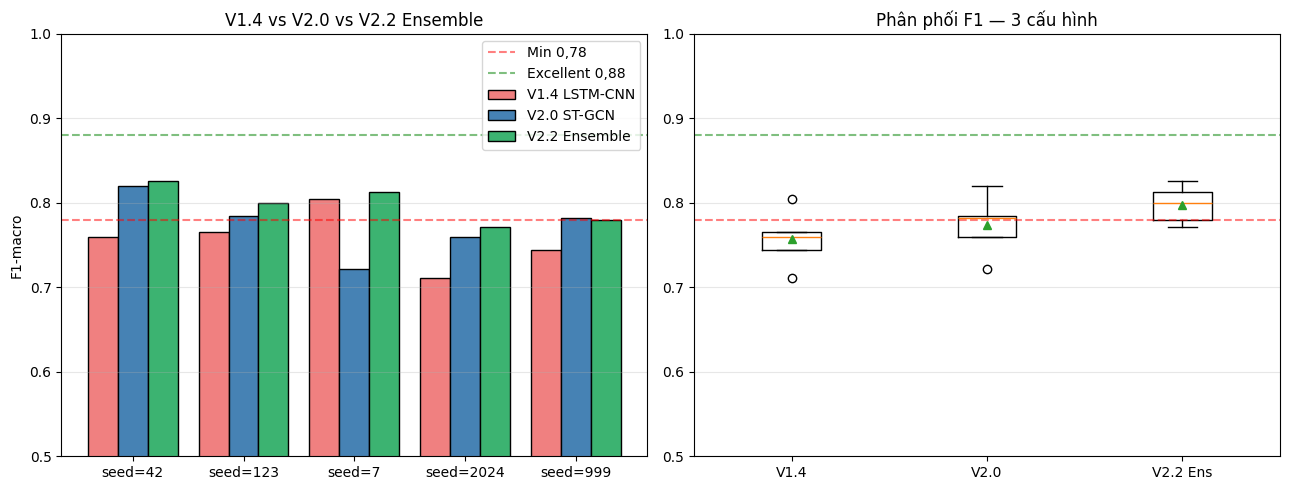

✓ Saved plot


In [ ]:
# Plot so sánh 3 mô hình
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(SEEDS)); w = 0.27
v14_vals = [r["f1_v14"] for r in results]
v20_vals = [r["f1_v20"] for r in results]
ens_vals = [r["f1_ensemble"] for r in results]

axes[0].bar(x - w, v14_vals, w, label='V1.4 LSTM-CNN', color='lightcoral', edgecolor='black')
axes[0].bar(x, v20_vals, w, label='V2.0 ST-GCN', color='steelblue', edgecolor='black')
axes[0].bar(x + w, ens_vals, w, label='V2.2 Ensemble', color='mediumseagreen', edgecolor='black')
axes[0].axhline(y=0.78, color='red', linestyle='--', alpha=0.5, label='Min 0,78')
axes[0].axhline(y=0.88, color='green', linestyle='--', alpha=0.5, label='Excellent 0,88')
axes[0].set_xticks(x); axes[0].set_xticklabels([f"seed={s}" for s in SEEDS])
axes[0].set_ylabel('F1-macro'); axes[0].set_title('V1.4 vs V2.0 vs V2.2 Ensemble')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

axes[1].boxplot([v14_vals, v20_vals, ens_vals],
                labels=['V1.4', 'V2.0', 'V2.2 Ens'], showmeans=True)
axes[1].axhline(y=0.78, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=0.88, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Phân phối F1 — 3 cấu hình')
axes[1].grid(axis='y', alpha=0.3); axes[1].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/v2.2_ensemble_compare.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved plot")

## 7. Bước kế tiếp

Gửi tôi `V2.2_ensemble_summary.json`:

| V2.2 Mean F1 | Kết quả |
|---:|---|
| ≥ 0,85 | 🎉 Xuất sắc, kết thúc V2.x. Tiến V3.0 pipeline E2E + demo |
| 0,80 - 0,84 | ✓ Vượt mục tiêu chính. Có thể dừng hoặc thêm Rule-based để tăng 0,02-0,05 |
| 0,78 - 0,79 | Đạt ngưỡng tối thiểu. Có thể thêm Rule-based |
| < 0,78 | Phân tích nguyên nhân: ensemble không hợp lực, có thể cần V2.1 Transformer |